# Lab Assignment: Implementation of DBSCAN Algorithm from Scratch


**Student Name:** Lepmuhang Sherma  
**Roll No:** 023-332  


## 1. Introduction & Theoretical Background

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** is an unsupervised, non-parametric clustering algorithm. Unlike K-Means, which assumes spherical clusters and requires specifying $K$ upfront, DBSCAN groups points based on spatial density and can discover arbitrarily shaped clusters.

### Key Concepts
- **$\epsilon$-Neighborhood ($\text{eps}$):** The radius around a point defining its local neighborhood.
- **Minimum Points ($\text{min\_samples}$):** The minimum number of points required within an $\epsilon$-neighborhood to form a dense region.
- **Core Point:** A point with at least $\text{min\_samples}$ within its $\epsilon$-radius.
- **Border Point:** A point that is within $\epsilon$-distance of a Core Point but has fewer than $\text{min\_samples}$ in its own neighborhood.
- **Noise / Outlier:** Any point that is neither a Core Point nor a Border Point (labeled as `-1`).

## 2. Lab Objectives

- Implement the complete DBSCAN algorithm from scratch using `NumPy` without relying on high-level machine learning libraries.
- Formulate neighborhood query mechanisms using Euclidean distance vectorization.
- Evaluate model capability on non-linearly separable datasets (`make_moons`).
- Analyze noise identification and cluster expansion behavior.

## 3. Mathematical Formulation

### 1. Distance Metric (Euclidean Distance)
For two $n$-dimensional points $p$ and $q$:

$$d(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2} = \| p - q \|_2$$

### 2. $\epsilon$-Neighborhood Condition
The neighborhood $\mathcal{N}_{\epsilon}(p)$ of a point $p$ is defined as:

$$\mathcal{N}_{\epsilon}(p) = \{ q \in X \mid d(p, q) \le \epsilon \}$$

### 3. Core Point Condition
A point $p$ is a core point if:

$$|\mathcal{N}_{\epsilon}(p)| \ge \text{min\_samples}$$

# ==========================================
# 1. Imports and Environment Setup
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Set plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [ ]:
# ==========================================
# 1. Imports and Environment Setup
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Set plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [ ]:
# ==========================================
# 2. DBSCAN Class Implementation
# ==========================================
class DBSCANFromScratch:
    def __init__(self, eps=0.2, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples

    def _get_neighbors(self, X, point_idx):
        """Find indices of all points within eps distance of X[point_idx]."""
        distances = np.linalg.norm(X - X[point_idx], axis=1)
        return np.where(distances <= self.eps)[0]

    def fit_predict(self, X):
        n_samples = X.shape[0]
        # Initialize all points as unvisited/noise (-1)
        labels = np.full(n_samples, -1)
        visited = np.zeros(n_samples, dtype=bool)
        cluster_id = 0

        for i in range(n_samples):
            if visited[i]:
                continue

            visited[i] = True
            neighbors = self._get_neighbors(X, i)

            # If neighbors < min_samples, mark as noise (-1)
            if len(neighbors) < self.min_samples:
                labels[i] = -1
            else:
                # Core point found: Expand Cluster
                labels[i] = cluster_id
                seeds = list(neighbors)

                # Process all reachable points in density queue
                while seeds:
                    curr_point = seeds.pop(0)

                    if not visited[curr_point]:
                        visited[curr_point] = True
                        curr_neighbors = self._get_neighbors(X, curr_point)

                        # If current neighbor is also a core point, expand its neighborhood
                        if len(curr_neighbors) >= self.min_samples:
                            seeds.extend(curr_neighbors)

                    # If neighbor is not yet assigned to any cluster (or was marked noise)
                    if labels[curr_point] == -1:
                        labels[curr_point] = cluster_id

                cluster_id += 1

        return labels

In [ ]:
# ==========================================
# 3. Dataset Generation & Model Execution
# ==========================================
# Generate synthetic non-linear dataset (Two Moons)
X, _ = make_moons(n_samples=300, noise=0.08, random_state=42)

# Instantiate and fit custom DBSCAN model
dbscan_custom = DBSCANFromScratch(eps=0.2, min_samples=5)
custom_labels = dbscan_custom.fit_predict(X)

# Output summary
unique_clusters = np.unique(custom_labels)
print("Unique Clusters Found (Scratch):", unique_clusters)
print("Number of Noise Points:", np.sum(custom_labels == -1))

Unique Clusters Found (Scratch): [0 1]
Number of Noise Points: 0


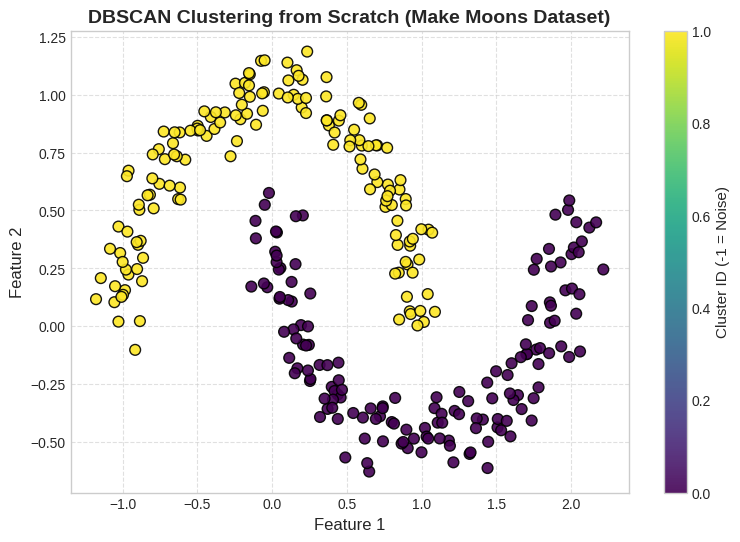

In [ ]:
# ==========================================
# 4. Visualization of Results
# ==========================================
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X[:, 0], X[:, 1],
    c=custom_labels,
    cmap='viridis',
    edgecolors='k',
    s=60,
    alpha=0.9
)
plt.title("DBSCAN Clustering from Scratch (Make Moons Dataset)", fontsize=14, fontweight='bold')
plt.xlabel("Feature 1", fontsize=12)
plt.ylabel("Feature 2", fontsize=12)
cbar = plt.colorbar(scatter)
cbar.set_label("Cluster ID (-1 = Noise)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 4. Results & Key Observations

| Parameter | Value | Description |
| :--- | :--- | :--- |
| **Dataset** | `make_moons` | 300 samples, noise = 0.08 |
| **$\epsilon$ (`eps`)** | `0.2` | Neighborhood search radius |
| **`min_samples`** | `5` | Minimum points for core point designation |
| **Clusters Identified** | `2` | Successfully separated upper and lower moons |
| **Noise Handling** | Label `-1` | Isolated points outside dense regions |

### Key Takeaways
1. **Handling Non-Convex Structures:** DBSCAN correctly identifies the two interleaved moon shapes where distance-centroid methods (like K-Means) fail.
2. **Noise Robustness:** Outliers in sparse regions are marked as noise (`-1`) rather than corrupting cluster boundaries.